In [82]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [83]:
PATH = 'mimic-iii-clinical-database-demo-1.4/'

icu = pd.read_csv(PATH + 'ICUSTAYS.csv')
patients = pd.read_csv(PATH + 'PATIENTS.csv')
admissions = pd.read_csv(PATH + 'ADMISSIONS.csv')
labevents = pd.read_csv(PATH + 'LABEVENTS.csv')


In [85]:
creatinine = (
    labevents[labevents['itemid'] == 50912]
    .groupby('subject_id')['valuenum']
    .mean()
    .reset_index()
)
creatinine.columns = ['subject_id', 'creatinine_mean']
creatinine['subject_id'] = creatinine['subject_id'].astype(int)

In [86]:
df = icu.merge(patients[['subject_id', 'gender', 'dob']], on='subject_id', how='left')
df = df.merge(admissions[['hadm_id', "admission_type", 'insurance']], on='hadm_id', how='left')
df = df.merge(creatinine, on='subject_id', how='left')

In [87]:
# admit time?
df['intime'] = pd.to_datetime(df['intime'])

# make dob a datetime object
df['dob'] = pd.to_datetime(df['dob'])

# subtract dob and admit time to find age
df['age'] = (df['intime'] - df['dob']).dt.days / 365.25
df['age'] = df['age'].clip(upper=90)

df['gender'] = df['gender'].map({'M':1, 'F':0})

print(df[['subject_id', 'los', 'age', 'gender', 'first_careunit']].head(10))
print(f"\nShape: {df.shape}")
print(f"LOS stats:\n{df["los"].describe()}")


   subject_id      los        age  gender first_careunit
0       10006   1.6325  70.633812       0           MICU
1       10011  13.8507  36.188912       0           MICU
2       10013   2.6499  87.082820       0           MICU
3       10017   2.1436  73.683778       0            CCU
4       10019   1.2938  48.898015       1           MICU
5       10026   2.4056  90.000000       0           SICU
6       10027   7.2616  82.491444       0           CSRU
7       10029   2.2624  78.450376       1           SICU
8       10032   3.7120  88.024641       1           MICU
9       10033   1.0695  81.623546       0           SICU

Shape: (136, 18)
LOS stats:
count    136.000000
mean       4.452457
std        6.196828
min        0.105900
25%        1.233525
50%        2.111450
75%        4.329050
max       35.406500
Name: los, dtype: float64


In [81]:
TARGET = 'los'
FEATURES = ['age', 'gender', 'creatinine_mean']

df_clean = df[FEATURES + [TARGET]].dropna()

X = df_clean[FEATURES]
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_hat = model.predict(X_test)

print(f'R²:          {r2_score(y_test, y_hat):.3f}')
print(f'RMSE:        {np.sqrt(mean_squared_error(y_test, y_hat)):.3f} days')
print(f'Coefficient: {model.coef_[0]:.4f}')
print(f'Intercept:   {model.intercept_:.4f}')

R²:          0.253
RMSE:        3.133 days
Coefficient: -0.1414
Intercept:   16.5716


ValueError: x and y must be the same size

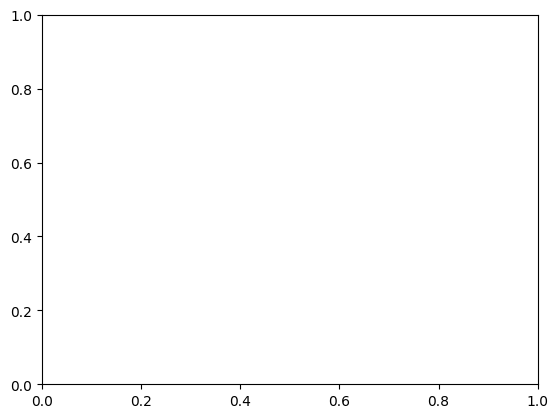

In [80]:
# Plot
plt.scatter(X_test, y_test, alpha=0.4, s=15, label='Actual')
x_range = np.linspace(X_test[FEATURE].min(), X_test[FEATURE].max(), 100).reshape(-1, 1)
plt.plot(x_range, model.predict(x_range), color='red', linewidth=2, label='Regression line')
plt.xlabel('Age')
plt.ylabel('ICU LOS (days)')
plt.title('Age vs ICU Length of Stay')
plt.legend()
plt.show()